# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [ ]:
LabelEncoder ha asignado un número entero a cada categoría, lo que puede ser útil para algoritmos que pueden interpretar esta relación ordinal. Por otro lado, OneHotEncoder ha creado columnas binarias para cada categoría, lo que evita cualquier suposición de orden entre las categorías y es útil para algoritmos que no pueden manejar relaciones ordinales.

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

/tmp/ipykernel_14071/4257753562.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=data, ax=axes[0], palette='pastel')
/tmp/ipykernel_14071/4257753562.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex_label', data=data, ax=axes[1], palette='magma')


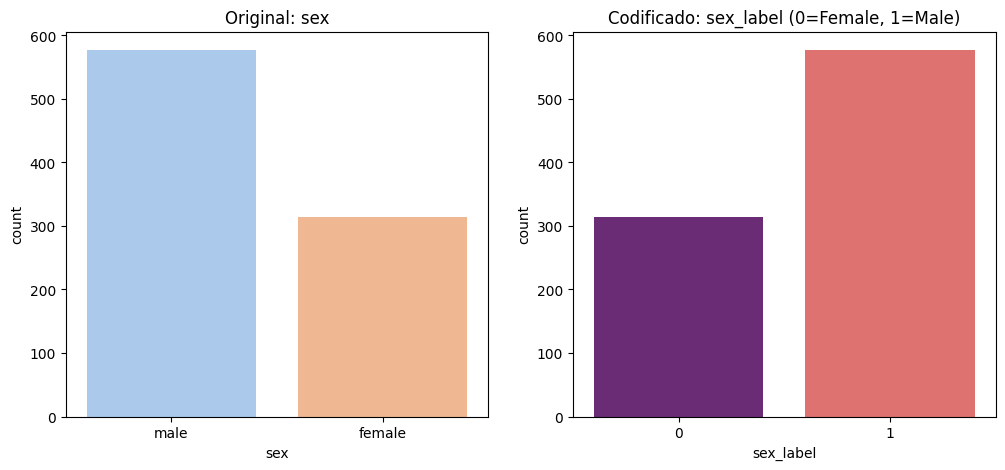

      sex  sex_label
0    male          1
1  female          0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Cargar datos
data = sns.load_dataset('titanic')

# Codificar
le = LabelEncoder()
data['sex_label'] = le.fit_transform(data['sex'])

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='sex', data=data, ax=axes[0], palette='pastel')
axes[0].set_title('Original: sex')

sns.countplot(x='sex_label', data=data, ax=axes[1], palette='magma')
axes[1].set_title('Codificado: sex_label (0=Female, 1=Male)')

plt.show()

# Demostración del resultado
print(data[['sex', 'sex_label']].drop_duplicates())

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [9]:
# Aplicar OneHotEncoder (usando get_dummies para simplicidad en pandas)
onehot_class = pd.get_dummies(data['class'], prefix='class')
print("Nuevas columnas creadas:")
print(onehot_class.head())

# Ventajas
# 1. Evita el sesgo de orden: No hay una relación matemática de magnitud entre clases.
# 2. Compatibilidad: Muchos modelos lineales requieren que las variables sean binarias.

Nuevas columnas creadas:
   class_First  class_Second  class_Third
0        False         False         True
1         True         False        False
2        False         False         True
3         True         False        False
4        False         False         True


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [ ]:
OneHotEncoder ha creado columnas binarias para cada categoría, lo que evita cualquier suposición de orden entre las categorías y es útil para algoritmos que no pueden manejar relaciones ordinales. 
OrdinalEncoder, por otro lado, asigna un número entero a cada categoría, lo que puede ser útil para algoritmos que pueden interpretar esta relación ordinal.